# Task 4 — Open-Set Recognition (OSR)

This notebook is the primary entry point. It trains and selects every model using CIFAR-10 only, fixes all score definitions and validation thresholds, and only then loads the fixed CIFAR-100 test unknowns. Run cells in order.

**Fixed unknown groups (never revised):** near = `bus, pickup_truck, motorcycle, tractor, wolf, fox, leopard, camel`; far = `bottle, bowl, chair, clock, keyboard, mushroom, sunflower, wardrobe`.

## 1. Setup and configuration

In [1]:
from pathlib import Path
import sys, yaml, torch, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'task4': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
TASK = ROOT / 'task4'
RESULTS = TASK / 'results'
CACHE = RESULTS / 'cache'
CHECKPOINTS = RESULTS / 'checkpoints'
DATA_ROOT = TASK / 'data' / 'cifar'
for directory in (CACHE, CHECKPOINTS): directory.mkdir(parents=True, exist_ok=True)
SEED = 6304
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print('Device:', DEVICE)

from task4.methods.vanilla import seed_everything
seed_everything(SEED)

def config(name):
    with (TASK / 'configs' / f'{name}.yaml').open() as handle:
        return yaml.safe_load(handle)

VANILLA_CFG, GCSC_CFG, PROSER_CFG = map(config, ('vanilla', 'gcsc', 'proser'))
RUN_TRAINING = True  # Set False only when all selected checkpoints already exist.
FORCE_CACHE = False  # Existing per-model caches prevent repeated forward passes.

Device: cuda


## 2. CIFAR-10 split and CIFAR-ResNet-18

The official CIFAR-10 training partition is split 90/10 within each class with seed 6304. The model uses a 3×3, stride-1 stem and no initial max-pool. All loaders use `num_workers=0`.

In [2]:
from task4.data.cifar10 import build_cifar10_loaders
from task4.models import resnet18_cifar

known = build_cifar10_loaders(DATA_ROOT, batch_size=128, seed=SEED, randaugment=False,
                                    download=True, pin_memory=DEVICE.type == 'cuda')
assert len(known['train_indices']) == 45000 and len(known['val_indices']) == 5000
assert all(loader.num_workers == 0 for key, loader in known.items() if hasattr(loader, 'num_workers'))
resnet18_cifar(10)

/home/ayaan/custom_venvs/cuda_pytorch/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFARResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2):

## 3. Fixed CIFAR-100 protocol declaration

The class lists were declared above, but CIFAR-100 is intentionally **not loaded here**. Its training partition is never used. Construction of the two 800-image test-only groups is deferred until Section 8, after checkpoints and score definitions are fixed.

## 4. Vanilla training, selection, and known-data caching

In [3]:
from task4.methods.vanilla import train_vanilla, known_accuracy
from task4.extract_outputs import extract_or_load

vanilla_path = CHECKPOINTS / 'vanilla_seed6304.pt'
if RUN_TRAINING or not vanilla_path.exists():
    vanilla, vanilla_history = train_vanilla(known['train'], known['val'], VANILLA_CFG, vanilla_path, DEVICE)
else:
    vanilla = resnet18_cifar(10)
    vanilla.load_state_dict(torch.load(vanilla_path, map_location='cpu', weights_only=False)['model'])
    vanilla = vanilla.to(DEVICE, memory_format=torch.channels_last)
print(f'Vanilla CIFAR-10 test CSA: {known_accuracy(vanilla, known["test"], DEVICE):.4f}')

# The augmented train pass is cached once for auditability; Mahalanobis uses train_unaug only.
vanilla_cache = {
    'train_aug': extract_or_load(vanilla, known['train'], DEVICE, CACHE/'vanilla_train_aug.pt', FORCE_CACHE),
    'train_unaug': extract_or_load(vanilla, known['train_eval'], DEVICE, CACHE/'vanilla_train_unaug.pt', FORCE_CACHE),
    'val': extract_or_load(vanilla, known['val'], DEVICE, CACHE/'vanilla_val.pt', FORCE_CACHE),
    'test': extract_or_load(vanilla, known['test'], DEVICE, CACHE/'vanilla_test.pt', FORCE_CACHE),
}

Epoch 1/100:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 5/100:   0%|          | 0/352 [00:00<?, ?it/s]

...

Vanilla CIFAR-10 test CSA: 0.9470


Extract:   0%|          | 0/352 [00:00<?, ?it/s]

Extract:   0%|          | 0/352 [00:00<?, ?it/s]

Extract:   0%|          | 0/40 [00:00<?, ?it/s]

Extract:   0%|          | 0/79 [00:00<?, ?it/s]

## 5. Frozen-model post-hoc scores

Every function below is pure over cached tensors. Mahalanobis class means and one shared diagonal covariance are fit only on unaugmented CIFAR-10 training features, with `1e-6` variance stabilization. No forward pass is repeated to change a score or threshold.

In [4]:
from task4.scores import (msp_unknownness, mls_unknownness, energy_unknownness,
                          fit_shared_diagonal_gaussian, mahalanobis_unknownness)
from task4.evaluation.thresholds import calibrate_threshold

MAH_MEANS, MAH_VARIANCE = fit_shared_diagonal_gaussian(
    vanilla_cache['train_unaug']['features'], vanilla_cache['train_unaug']['labels'], eps=1e-6)

SCORE_FUNCTIONS = {
    'MSP': lambda cache: msp_unknownness(cache['logits'][:, :10]),
    'MLS': lambda cache: mls_unknownness(cache['logits'][:, :10]),
    'Energy': lambda cache: energy_unknownness(cache['logits'][:, :10]),
    'Mahalanobis': lambda cache: mahalanobis_unknownness(cache['features'], MAH_MEANS, MAH_VARIANCE),
}
# Thresholds are now fixed using known validation data only.
VANILLA_THRESHOLDS = {name: calibrate_threshold(fn(vanilla_cache['val']))
                      for name, fn in SCORE_FUNCTIONS.items()}
VANILLA_THRESHOLDS

{'MSP': 0.1617516130208969,
 'MLS': -5.745121002197266,
 'Energy': -5.937827110290527,
 'Mahalanobis': 3015.2255859375}

## 6. GCSC training and caching

In [5]:
from task4.methods.gcsc import train_gcsc

gcsc_known = build_cifar10_loaders(DATA_ROOT, 128, SEED, randaugment=True,
                                         download=False, pin_memory=DEVICE.type == 'cuda')
gcsc_path = CHECKPOINTS / 'gcsc_seed6304.pt'
if RUN_TRAINING or not gcsc_path.exists():
    gcsc, gcsc_history = train_gcsc(gcsc_known['train'], gcsc_known['val'], GCSC_CFG, gcsc_path, DEVICE)
else:
    gcsc = resnet18_cifar(10)
    gcsc.load_state_dict(torch.load(gcsc_path, map_location='cpu', weights_only=False)['model'])
    gcsc = gcsc.to(DEVICE, memory_format=torch.channels_last)

gcsc_cache = {split: extract_or_load(gcsc, gcsc_known[loader], DEVICE, CACHE/f'gcsc_{split}.pt', FORCE_CACHE)
              for split, loader in {'train_unaug':'train_eval', 'val':'val', 'test':'test'}.items()}

/home/ayaan/custom_venvs/cuda_pytorch/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch 1/100:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/352 [00:00<?, ?it/s]

...

Epoch 99/100:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/352 [00:00<?, ?it/s]

Extract:   0%|          | 0/352 [00:00<?, ?it/s]

Extract:   0%|          | 0/40 [00:00<?, ?it/s]

Extract:   0%|          | 0/79 [00:00<?, ?it/s]

## 7. PROSER placeholders, manifold mixup, training, and caching

PROSER starts from the selected Vanilla checkpoint and appends five random dummy outputs. Half 1 of each batch uses the classifier-placeholder loss: ordinary classification plus a masked-target term that makes the strongest dummy the best remaining response (β=1). Half 2 mixes different-class features after layer2 using λ~Beta(2,2), then trains the strongest dummy response as the data placeholder (γ=0.1). Both losses reduce the five dummy logits to their maximum, matching the paper's multi-placeholder rule.

In [6]:
from task4.methods.proser import PROSER, train_proser, placeholder_unknownness

proser_path = CHECKPOINTS / 'proser_seed6304.pt'
if RUN_TRAINING or not proser_path.exists():
    proser = PROSER.from_vanilla_checkpoint(vanilla_path, num_dummy=5)
    proser, proser_history = train_proser(proser, known['train'], known['val'], PROSER_CFG, proser_path, DEVICE)
else:
    proser = PROSER(10, 5)
    proser.load_state_dict(torch.load(proser_path, map_location='cpu', weights_only=False)['model'])
    proser = proser.to(DEVICE, memory_format=torch.channels_last)

proser_cache = {split: extract_or_load(proser, known[loader], DEVICE, CACHE/f'proser_{split}.pt', FORCE_CACHE)
                for split, loader in {'train_unaug':'train_eval', 'val':'val', 'test':'test'}.items()}
# Both PROSER rules are fixed here, before any unknown is loaded. CSA always uses logits[:, :10].
PROSER_MLS_THRESHOLD = calibrate_threshold(mls_unknownness(proser_cache['val']['logits'][:, :10]))
PROSER_PLACEHOLDER_THRESHOLD = calibrate_threshold(placeholder_unknownness(proser_cache['val']['logits']))

Epoch 1/50:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 5/50:   0%|          | 0/352 [00:00<?, ?it/s]

...

Epoch 49/50:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/352 [00:00<?, ?it/s]

Extract:   0%|          | 0/352 [00:00<?, ?it/s]

Extract:   0%|          | 0/40 [00:00<?, ?it/s]

Extract:   0%|          | 0/79 [00:00<?, ?it/s]

## 8. Optional RPL extension

RPL is not implemented in this required run. Consequently no `rpl_seed6304.pt`, comparison row, or `rpl_notes.md` is emitted. This avoids presenting an unvalidated approximation as Chen et al.'s method.

## 9. Common evaluation — first access to CIFAR-100 unknowns

At this point all checkpoints, score definitions, and validation-only thresholds are frozen. The next cell is the first construction or model access of the fixed CIFAR-100 test groups.

In [7]:
from task4.data.cifar100_unknowns import build_unknown_loaders, NEAR_CLASSES, FAR_CLASSES

unknown = build_unknown_loaders(DATA_ROOT, 128, download=True, pin_memory=DEVICE.type == 'cuda')
assert len(unknown['near'].dataset) == len(unknown['far'].dataset) == 800
models = {'vanilla': vanilla, 'gcsc': gcsc, 'proser': proser}
for model_name, model in models.items():
    for group in ('near', 'far'):
        extract_or_load(model, unknown[group], DEVICE, CACHE/f'{model_name}_{group}.pt', FORCE_CACHE)
print('Cached one batched forward pass per model/group; subsequent evaluation is cache-only.')

100%|██████████████████████████████████████████████████| 169M/169M [21:02<00:00, 134kB/s]


Extract:   0%|          | 0/7 [00:00<?, ?it/s]

Extract:   0%|          | 0/7 [00:00<?, ?it/s]

Extract:   0%|          | 0/7 [00:00<?, ?it/s]

Extract:   0%|          | 0/7 [00:00<?, ?it/s]

Extract:   0%|          | 0/7 [00:00<?, ?it/s]

Extract:   0%|          | 0/7 [00:00<?, ?it/s]

Cached one batched forward pass per model/group; subsequent evaluation is cache-only.


Figure: Vanilla score distributions for CIFAR-10 known, near unknown, and far unknown samples


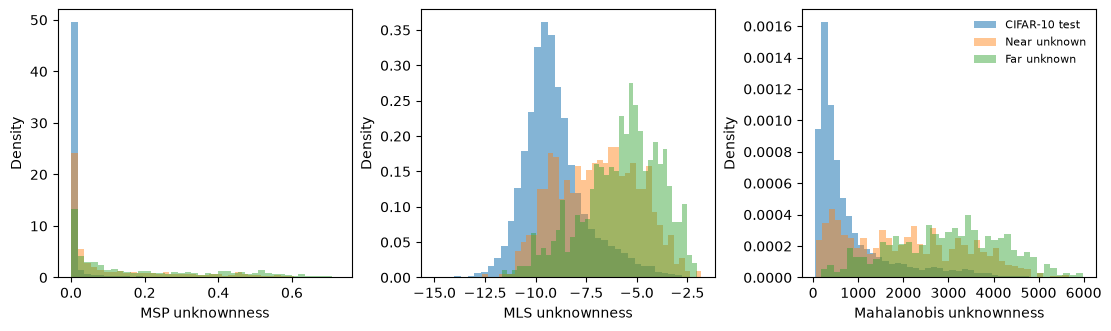

,score,threshold,near_auroc,far_auroc,all_auroc,known_test_acceptance,near_rejection,far_rejection,all_rejection,near_fpr_at_95_tpr,far_fpr_at_95_tpr,all_fpr_at_95_tpr
0,MSP,0.1618,0.8111,0.8955,0.8533,0.9502,0.2838,0.4362,0.3600,0.7163,0.5638,0.6400
1,MLS,-5.7451,0.7934,0.8943,0.8438,0.9544,0.3062,0.5500,0.4281,0.6938,0.4500,0.5719
2,Energy,-5.9378,0.7933,0.8952,0.8443,0.9562,0.3050,0.5625,0.4338,0.6950,0.4375,0.5662
3,Mahalanobis,3015.2256,0.7928,0.9178,0.8553,0.9520,0.2700,0.5062,0.3881,0.7300,0.4938,0.6119


,model,score,csa,threshold,near_auroc,far_auroc,all_auroc,known_test_acceptance,near_rejection,far_rejection,all_rejection,near_fpr_at_95_tpr,far_fpr_at_95_tpr,all_fpr_at_95_tpr
0,Vanilla,MLS,0.9470,-5.7451,0.7934,0.8943,0.8438,0.9544,0.3062,0.5500,0.4281,0.6938,0.4500,0.5719
1,Gcsc,MLS,0.9521,-6.0781,0.8040,0.9207,0.8624,0.9518,0.3425,0.6362,0.4894,0.6575,0.3638,0.5106
2,Proser,MLS,0.9448,-4.8750,0.8122,0.8710,0.8416,0.9554,0.3100,0.4550,0.3825,0.6900,0.5450,0.6175
3,PROSER,Placeholder Delta-P,0.9448,0.0001,0.7972,0.8813,0.8393,0.9567,0.2862,0.4475,0.3669,0.7138,0.5525,0.6331


In [8]:
from task4.evaluate_osr import evaluate_all

vanilla_table, trained_table, failures = evaluate_all(
    CACHE, RESULTS, unknown['dataset'].classes)
display(vanilla_table.round(4))
display(trained_table.round(4))

### Final-only failure analysis

The six rows below are the three most confidently accepted examples in each unknown group under Vanilla MLS. This inspection occurs after every quantitative result and cannot feed back into training, score design, or calibration.

,group,cache_row,source_index,unknown_class,predicted_cifar10_class,mls_unknownness,threshold,note
0,near,562,7133,bus,truck,-12.640625,-5.745121,semantically plausible
1,near,75,959,fox,dog,-11.664062,-5.745121,semantically plausible
2,near,410,5201,bus,truck,-11.296875,-5.745121,semantically plausible
3,far,100,1163,clock,airplane,-11.664062,-5.745121,surprising
4,far,507,6218,keyboard,frog,-11.523438,-5.745121,surprising
5,far,557,6729,mushroom,bird,-11.414062,-5.745121,surprising


Figure: Incorrectly accepted near and far unknowns under the validation-calibrated Vanilla MLS threshold


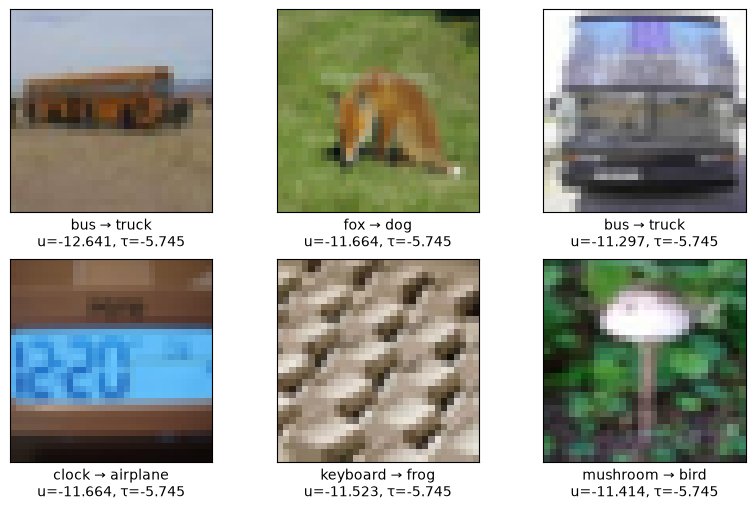

In [9]:
display(failures)
fig, axes = plt.subplots(2, 3, figsize=(8, 5), constrained_layout=True)
for ax, (_, row) in zip(axes.flat, failures.iterrows()):
    ax.imshow(unknown['dataset'].data[int(row.source_index)])
    ax.set_xlabel(f"{row.unknown_class} → {row.predicted_cifar10_class}\nu={row.mls_unknownness:.3f}, τ={row.threshold:.3f}")
    ax.set_xticks([]); ax.set_yticks([])
print('Figure: Incorrectly accepted near and far unknowns under the validation-calibrated Vanilla MLS threshold')
plt.show()

## 10. Artifact consolidation

In [10]:
required = [
    CHECKPOINTS/'vanilla_seed6304.pt', CHECKPOINTS/'gcsc_seed6304.pt', CHECKPOINTS/'proser_seed6304.pt',
    RESULTS/'vanilla_score_comparison.csv', RESULTS/'trained_model_comparison.csv',
    RESULTS/'score_distribution_or_roc_figure.png', RESULTS/'failure_cases.csv',
]
assert all(path.exists() for path in required), [str(path) for path in required if not path.exists()]
pd.DataFrame({'artifact': [str(path.relative_to(TASK)) for path in required],
              'exists': [path.exists() for path in required]})

,artifact,exists
0,results/checkpoints/vanilla_seed6304.pt,True
1,results/checkpoints/gcsc_seed6304.pt,True
2,results/checkpoints/proser_seed6304.pt,True
3,results/vanilla_score_comparison.csv,True
4,results/trained_model_comparison.csv,True
5,results/score_distribution_or_roc_figure.png,True
6,results/failure_cases.csv,True
